#Importaciones

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#Lectura y visualización del dataset

In [ ]:
df = pd.read_excel('/content/Mall Customers.xlsx')

In [ ]:
df.shape

(200, 7)

In [ ]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Education,object
Marital Status,object
Annual Income (k$),int64
Spending Score (1-100),int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [ ]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#Busqueda de nulos y duplicados

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Education,0
Marital Status,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
if 'CustomerID' in df.columns:
    duplicados_id = df['CustomerID'].duplicated().sum()
    print(f"\nCustomerID duplicados: {duplicados_id}")


CustomerID duplicados: 0


Resultado de la busqueda se detectaron 0 nulos en el dataset y 0 duplicados exactos, o en CustomerID

#Busqueda de sesgo de representación

In [ ]:
df.columns = df.columns.str.strip() # la columna 'Education' presentaba un espacio en blanco

In [ ]:
def resumen_categorico(df, columna):
    """Devuelve una tabla con conteo y porcentaje ordenados de mayor a menor."""
    conteo = df[columna].value_counts()
    porcentaje = df[columna].value_counts(normalize=True).round(3) * 100
    tabla = pd.DataFrame({
        'Cantidad': conteo,
        'Porcentaje (%)': porcentaje.round(1)
    })
    tabla.index.name = columna
    return tabla


estilo_headers = [
    {'selector': 'th', 'props': [
        ('background-color', '#1D1F20'),
        ('color', 'white'),
        ('font-weight', 'bold'),
        ('font-size', '12px')
    ]}
]

def mostrar_tabla(tabla, axis=None):
    styler = tabla.style.background_gradient(cmap='Blues', axis=axis)
    styler = styler.set_table_styles(estilo_headers)
    display(styler)


print("=== Distribución por Género ===")
mostrar_tabla(resumen_categorico(df, 'Gender'))

print("\n=== Distribución por Educación ===")
mostrar_tabla(resumen_categorico(df, 'Education'))

print("\n=== Distribución por Estado Civil ===")
mostrar_tabla(resumen_categorico(df, 'Marital Status'))


print("\n=== Estadísticos descriptivos ===")
desc = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].describe().round(2)
mostrar_tabla(desc, axis=1)

=== Distribución por Género ===


,Cantidad,Porcentaje (%)
Gender,,
F,112,56.000000
M,88,44.000000



=== Distribución por Educación ===


,Cantidad,Porcentaje (%)
Education,,
Graduate,67,33.500000
High School,40,20.000000
Uneducated,31,15.500000
Unknown,26,13.000000
College,17,8.500000
Doctorate,11,5.500000
Post-Graduate,8,4.000000



=== Distribución por Estado Civil ===


,Cantidad,Porcentaje (%)
Marital Status,,
Married,112,56.000000
Single,61,30.500000
Unknown,15,7.500000
Divorced,12,6.000000



=== Estadísticos descriptivos ===


,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.970000,26.260000,25.820000
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


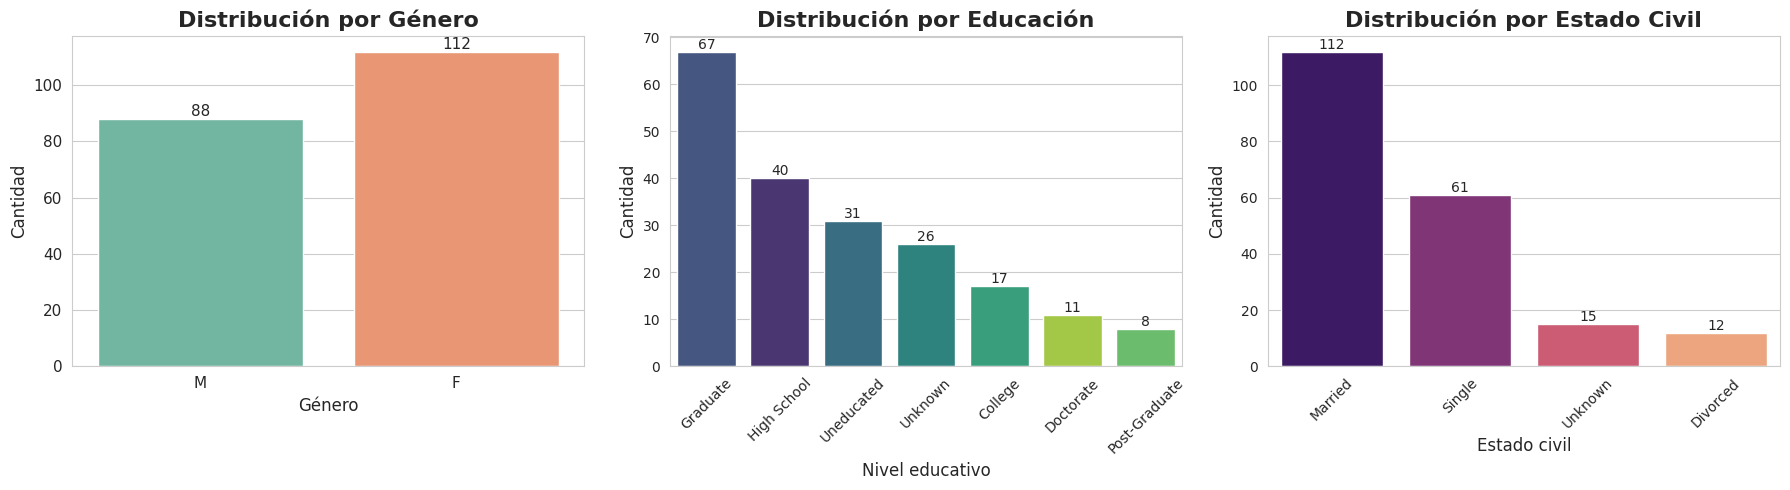

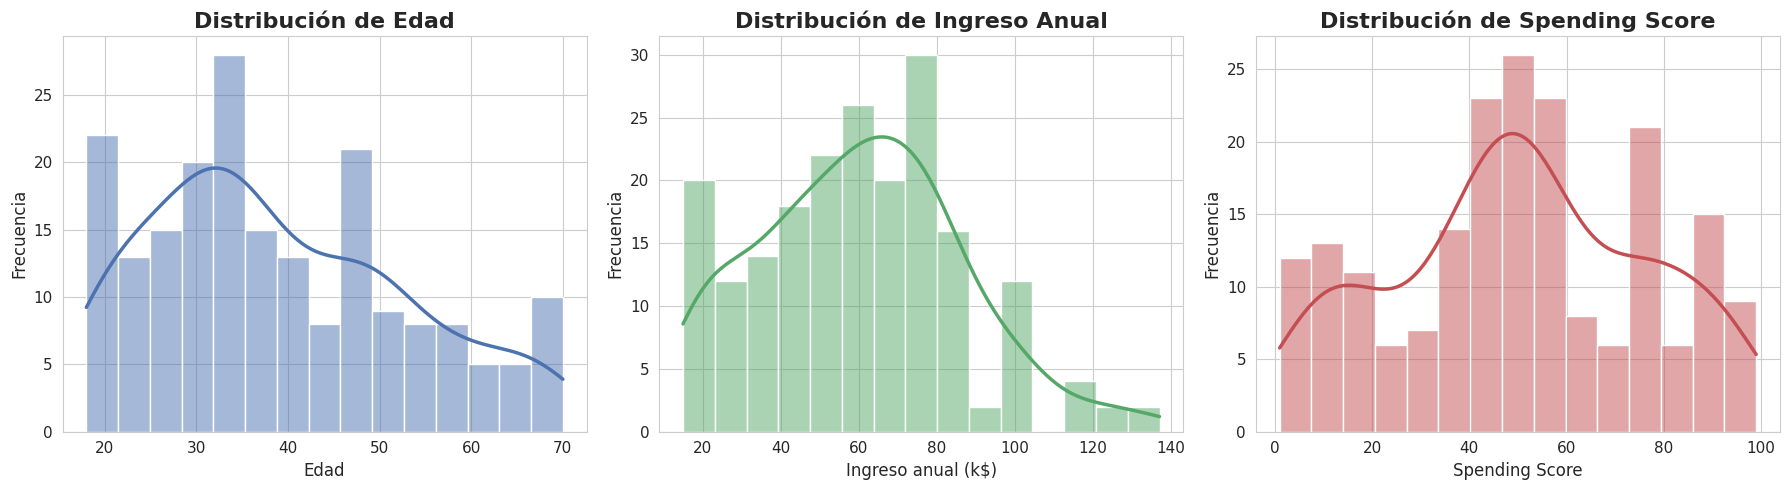

In [ ]:
sns.set_style("whitegrid")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Gender', hue='Gender', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Distribución por Género', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Género', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)
axes[0].tick_params(axis='both', labelsize=11)

for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11)

sns.countplot(data=df, x='Education', hue='Education', palette='viridis', legend=False,
              order=df['Education'].value_counts().index, ax=axes[1])
axes[1].set_title('Distribución por Educación', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Nivel educativo', fontsize=12)
axes[1].set_ylabel('Cantidad', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=10)

sns.countplot(data=df, x='Marital Status', hue='Marital Status', palette='magma', legend=False,
              order=df['Marital Status'].value_counts().index, ax=axes[2])
axes[2].set_title('Distribución por Estado Civil', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Estado civil', fontsize=12)
axes[2].set_ylabel('Cantidad', fontsize=12)
axes[2].tick_params(axis='x', rotation=45, labelsize=10)
for container in axes[2].containers:
    axes[2].bar_label(container, fontsize=10)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], bins=15, kde=True, color='#4C72B0',
             line_kws={'color': '#D62728', 'linewidth': 2.5}, ax=axes[0])
axes[0].set_title('Distribución de Edad', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Edad', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].tick_params(axis='both', labelsize=11)

sns.histplot(df['Annual Income (k$)'], bins=15, kde=True, color='#55A868',
             line_kws={'color': '#D62728', 'linewidth': 2.5}, ax=axes[1])
axes[1].set_title('Distribución de Ingreso Anual', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Ingreso anual (k$)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].tick_params(axis='both', labelsize=11)

sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True, color='#C44E52',
             line_kws={'color': '#1F1F1F', 'linewidth': 2.5}, ax=axes[2])
axes[2].set_title('Distribución de Spending Score', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Spending Score', fontsize=12)
axes[2].set_ylabel('Frecuencia', fontsize=12)
axes[2].tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()

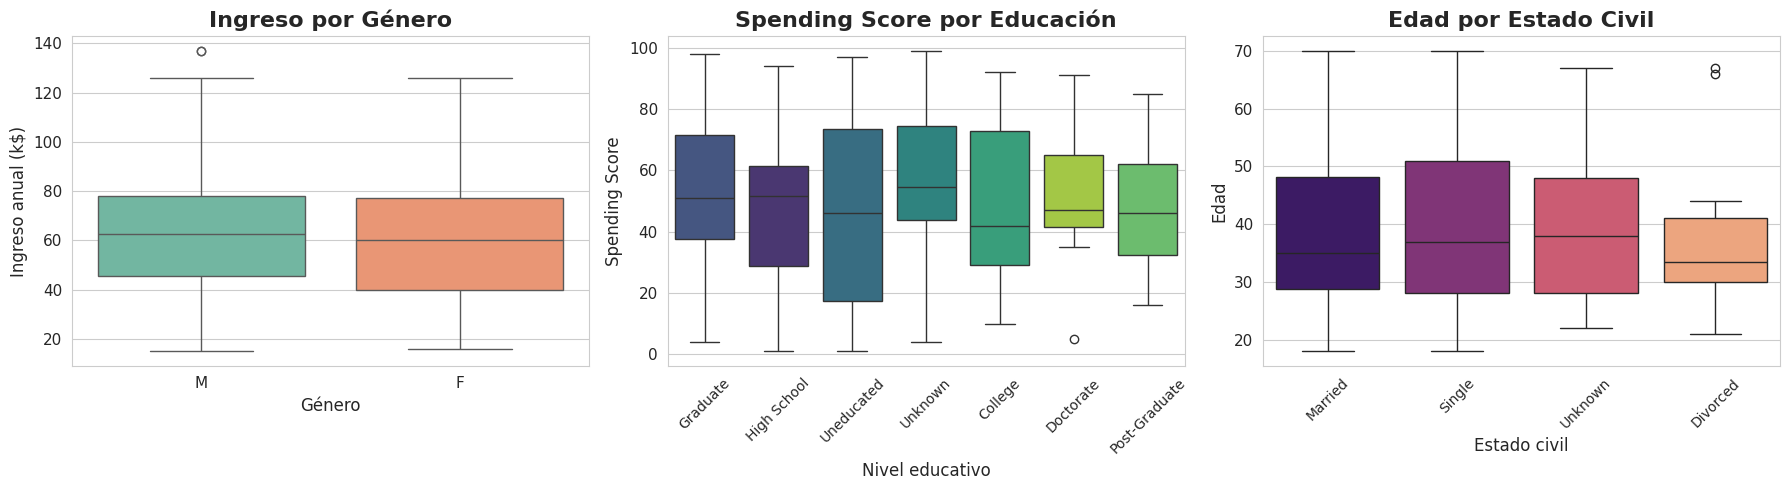

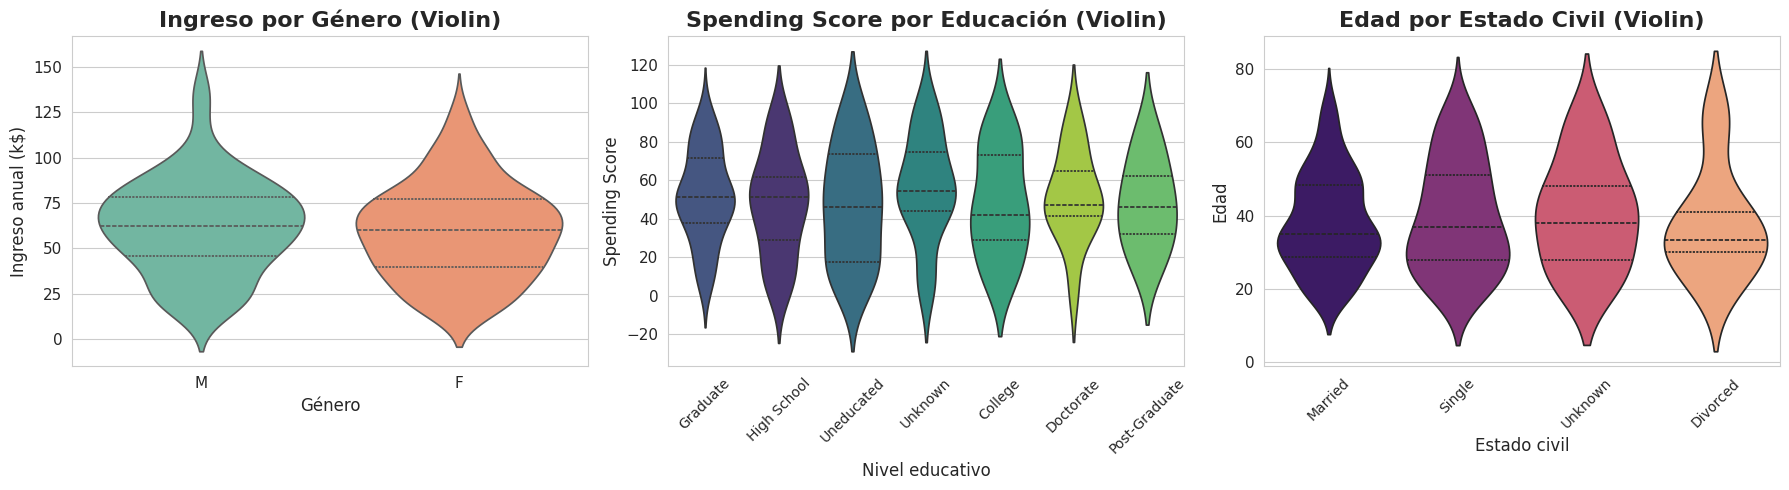

In [ ]:
sns.set_style("whitegrid")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Gender', y='Annual Income (k$)', hue='Gender', palette='Set2',
            legend=False, ax=axes[0])
axes[0].set_title('Ingreso por Género', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Género', fontsize=12)
axes[0].set_ylabel('Ingreso anual (k$)', fontsize=12)
axes[0].tick_params(axis='both', labelsize=11)

sns.boxplot(data=df, x='Education', y='Spending Score (1-100)', hue='Education', palette='viridis',
            legend=False, order=df['Education'].value_counts().index, ax=axes[1])
axes[1].set_title('Spending Score por Educación', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Nivel educativo', fontsize=12)
axes[1].set_ylabel('Spending Score', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
axes[1].tick_params(axis='y', labelsize=11)

sns.boxplot(data=df, x='Marital Status', y='Age', hue='Marital Status', palette='magma',
            legend=False, order=df['Marital Status'].value_counts().index, ax=axes[2])
axes[2].set_title('Edad por Estado Civil', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Estado civil', fontsize=12)
axes[2].set_ylabel('Edad', fontsize=12)
axes[2].tick_params(axis='x', rotation=45, labelsize=10)
axes[2].tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(data=df, x='Gender', y='Annual Income (k$)', hue='Gender', palette='Set2',
               legend=False, inner='quartile', ax=axes[0])
axes[0].set_title('Ingreso por Género (Violin)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Género', fontsize=12)
axes[0].set_ylabel('Ingreso anual (k$)', fontsize=12)
axes[0].tick_params(axis='both', labelsize=11)

sns.violinplot(data=df, x='Education', y='Spending Score (1-100)', hue='Education', palette='viridis',
               legend=False, inner='quartile', order=df['Education'].value_counts().index, ax=axes[1])
axes[1].set_title('Spending Score por Educación (Violin)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Nivel educativo', fontsize=12)
axes[1].set_ylabel('Spending Score', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
axes[1].tick_params(axis='y', labelsize=11)

sns.violinplot(data=df, x='Marital Status', y='Age', hue='Marital Status', palette='magma',
               legend=False, inner='quartile', order=df['Marital Status'].value_counts().index, ax=axes[2])
axes[2].set_title('Edad por Estado Civil (Violin)', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Estado civil', fontsize=12)
axes[2].set_ylabel('Edad', fontsize=12)
axes[2].tick_params(axis='x', rotation=45, labelsize=10)
axes[2].tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

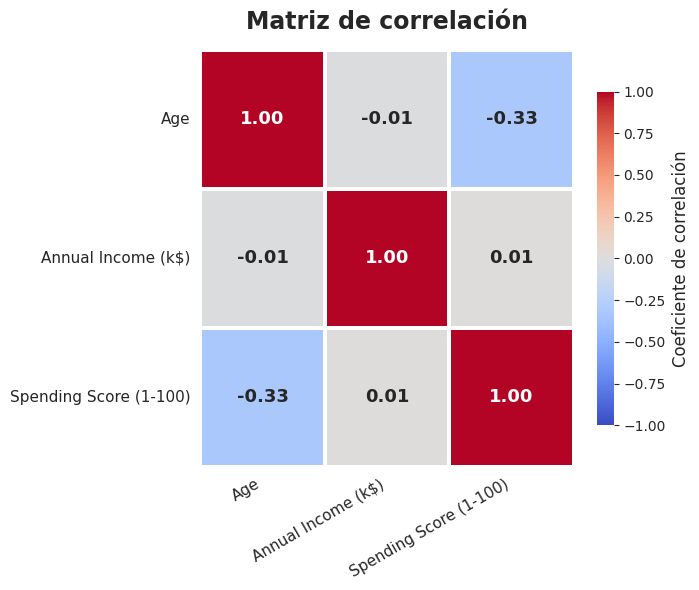

In [ ]:
sns.set_style("white")

plt.figure(figsize=(7, 6))
corr = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()

heatmap = sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    annot_kws={'fontsize': 13, 'fontweight': 'bold'},
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de correlación'}
)

plt.title('Matriz de correlación', fontsize=17, fontweight='bold', pad=15)
plt.xticks(fontsize=11, rotation=30, ha='right')
plt.yticks(fontsize=11, rotation=0)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Coeficiente de correlación', fontsize=12)

plt.tight_layout()
plt.show()

#Detección de valores atípicos

In [ ]:
def detectar_outliers_iqr(df, columna):
    """Calcula límites IQR y cuenta outliers para una columna numérica."""
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    return {
        'Columna': columna,
        'Límite inferior': round(lim_inf, 2),
        'Límite superior': round(lim_sup, 2),
        'Cantidad de outliers': len(outliers),
        'Porcentaje (%)': round(len(outliers) / len(df) * 100, 2)
    }

columnas_numericas = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
resumen_outliers = pd.DataFrame([detectar_outliers_iqr(df, col) for col in columnas_numericas])
resumen_outliers.set_index('Columna', inplace=True)

print("=== Resumen de outliers (método IQR) ===")
mostrar_tabla(resumen_outliers)

=== Resumen de outliers (método IQR) ===


,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje (%)
Columna,,,,
Age,-1.620000,79.380000,0,0.000000
Annual Income (k$),-13.250000,132.750000,2,1.000000
Spending Score (1-100),-22.620000,130.380000,0,0.000000


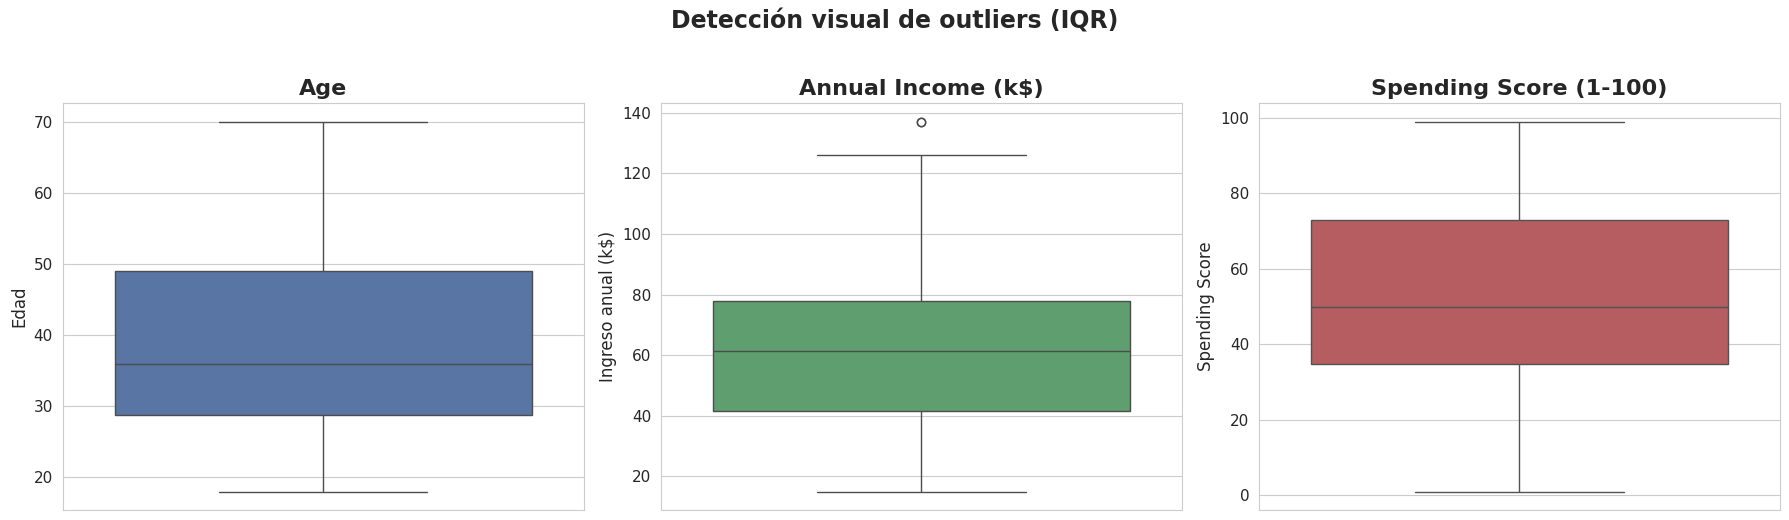

In [ ]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['Age'], color='#4C72B0', ax=axes[0])
axes[0].set_title('Age', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Edad', fontsize=12)
axes[0].tick_params(axis='both', labelsize=11)

sns.boxplot(y=df['Annual Income (k$)'], color='#55A868', ax=axes[1])
axes[1].set_title('Annual Income (k$)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Ingreso anual (k$)', fontsize=12)
axes[1].tick_params(axis='both', labelsize=11)

sns.boxplot(y=df['Spending Score (1-100)'], color='#C44E52', ax=axes[2])
axes[2].set_title('Spending Score (1-100)', fontsize=16, fontweight='bold')
axes[2].set_ylabel('Spending Score', fontsize=12)
axes[2].tick_params(axis='both', labelsize=11)

fig.suptitle('Detección visual de outliers (IQR)', fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

#Clustering (K-Means)

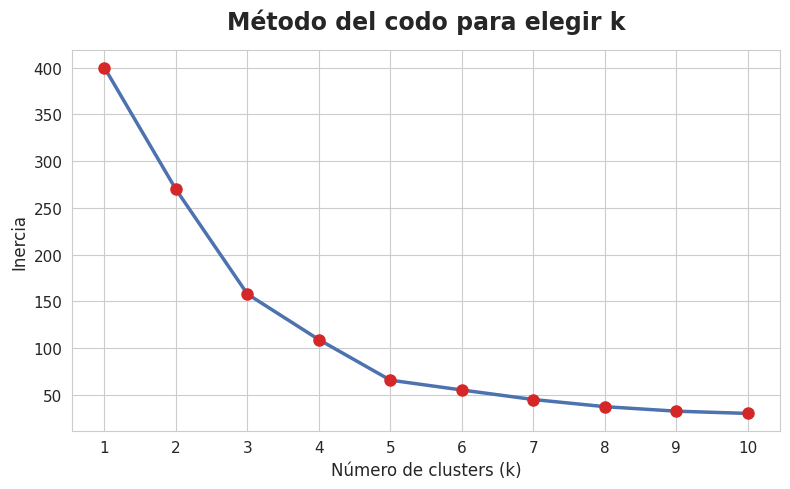

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


inercias = []
rango_k = range(1, 11)
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, marker='o', color='#4C72B0', linewidth=2.5, markersize=8,
         markerfacecolor='#D62728', markeredgecolor='#D62728')
plt.title('Método del codo para elegir k', fontsize=17, fontweight='bold', pad=15)
plt.xlabel('Número de clusters (k)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.xticks(list(rango_k), fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

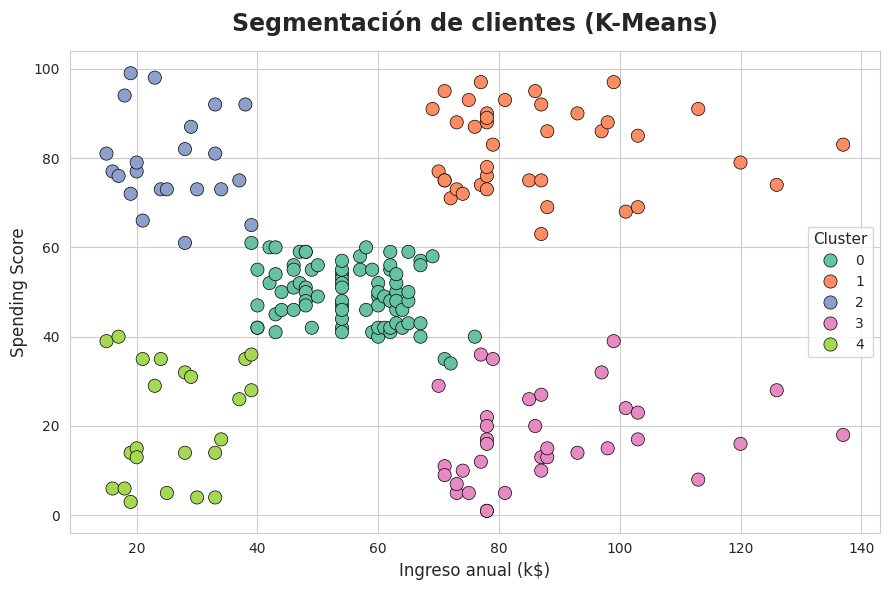

=== Cantidad de clientes por cluster ===


,Cantidad,Porcentaje (%)
Cluster,,
0,81,40.500000
1,39,19.500000
3,35,17.500000
4,23,11.500000
2,22,11.000000


In [ ]:
k_optimo = 5

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster', palette='Set2', s=90, edgecolor='black', linewidth=0.5
)
plt.title('Segmentación de clientes (K-Means)', fontsize=17, fontweight='bold', pad=15)
plt.xlabel('Ingreso anual (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.legend(title='Cluster', fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.show()


print("=== Cantidad de clientes por cluster ===")
mostrar_tabla(resumen_categorico(df, 'Cluster'))

#Relación entre clusters y variables demográficas (sesgo algorítmico)

In [ ]:
def crosstab_porcentaje(df, var_categorica, cluster_col='Cluster'):
    """Tabla cruzada: distribución porcentual de la variable categórica dentro de cada cluster."""
    tabla = pd.crosstab(df[cluster_col], df[var_categorica], normalize='index').round(3) * 100
    return tabla

print("=== Composición de Género por Cluster (%) ===")
mostrar_tabla(crosstab_porcentaje(df, 'Gender'), axis=1)

print("\n=== Composición de Educación por Cluster (%) ===")
mostrar_tabla(crosstab_porcentaje(df, 'Education'), axis=1)

print("\n=== Composición de Estado Civil por Cluster (%) ===")
mostrar_tabla(crosstab_porcentaje(df, 'Marital Status'), axis=1)

=== Composición de Género por Cluster (%) ===


Gender,F,M
Cluster,,
0,59.300000,40.700000
1,53.800000,46.200000
2,59.100000,40.900000
3,45.700000,54.300000
4,60.900000,39.100000



=== Composición de Educación por Cluster (%) ===


Education,College,Doctorate,Graduate,High School,Post-Graduate,Uneducated,Unknown
Cluster,,,,,,,
0,6.200000,7.400000,38.300000,19.800000,3.700000,9.900000,14.800000
1,10.300000,5.100000,33.300000,15.400000,5.100000,20.500000,10.300000
2,9.100000,4.500000,31.800000,18.200000,0.000000,9.100000,27.300000
3,11.400000,2.900000,22.900000,28.600000,5.700000,25.700000,2.900000
4,8.700000,4.300000,34.800000,17.400000,4.300000,17.400000,13.000000



=== Composición de Estado Civil por Cluster (%) ===


Marital Status,Divorced,Married,Single,Unknown
Cluster,,,,
0,6.200000,54.300000,33.300000,6.200000
1,10.300000,59.000000,25.600000,5.100000
2,0.000000,54.500000,27.300000,18.200000
3,5.700000,60.000000,31.400000,2.900000
4,4.300000,52.200000,30.400000,13.000000


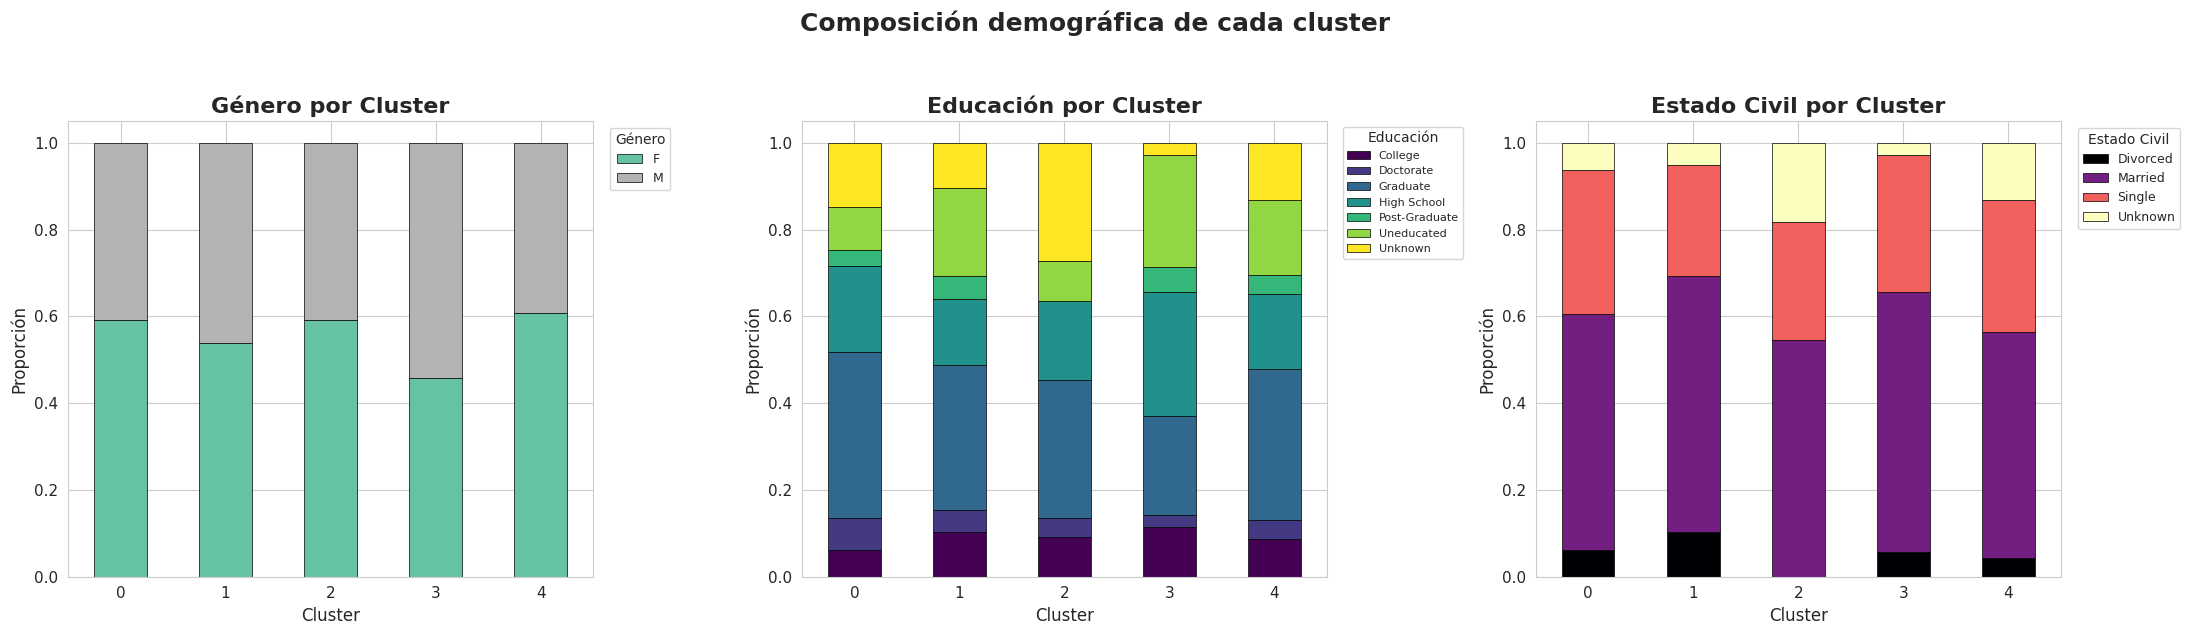

In [ ]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

pd.crosstab(df['Cluster'], df['Gender'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black', linewidth=0.5
)
axes[0].set_title('Género por Cluster', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Proporción', fontsize=12)
axes[0].tick_params(axis='both', labelsize=11, rotation=0)
axes[0].legend(title='Género', fontsize=9, title_fontsize=10,
               bbox_to_anchor=(1.02, 1), loc='upper left')

pd.crosstab(df['Cluster'], df['Education'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1], colormap='viridis', edgecolor='black', linewidth=0.5
)
axes[1].set_title('Educación por Cluster', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Proporción', fontsize=12)
axes[1].tick_params(axis='both', labelsize=11, rotation=0)
axes[1].legend(title='Educación', fontsize=8, title_fontsize=10,
               bbox_to_anchor=(1.02, 1), loc='upper left')

pd.crosstab(df['Cluster'], df['Marital Status'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[2], colormap='magma', edgecolor='black', linewidth=0.5
)
axes[2].set_title('Estado Civil por Cluster', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Cluster', fontsize=12)
axes[2].set_ylabel('Proporción', fontsize=12)
axes[2].tick_params(axis='both', labelsize=11, rotation=0)
axes[2].legend(title='Estado Civil', fontsize=9, title_fontsize=10,
               bbox_to_anchor=(1.02, 1), loc='upper left')

fig.suptitle('Composición demográfica de cada cluster', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

#Análisis ético

**Identificación de sesgos en los datos**

El dataset Mall Customers no presenta valores nulos ni registros duplicados, lo que descarta sesgos por datos faltantes de tipo técnico. Sin embargo, el análisis exploratorio identificó los siguientes sesgos de representación:

- **Género**: la muestra está compuesta por 56% mujeres (112) y 44% hombres (88), un desbalance moderado que puede afectar la generalización de cualquier modelo hacia el grupo subrepresentado.

- **Nivel educativo**: se detectó que un 13% de los registros (26 personas) están categorizados como "Unknown", es decir, información faltante disfrazada de categoría válida en lugar de un valor nulo real. Adicionalmente, los segmentos "Post-Graduate" (4%) y "Doctorate" (5,5%) tienen un tamaño muestral muy reducido, lo que limita la confiabilidad de cualquier conclusión sobre esos grupos.

- **Estado civil**: mismo patrón de dato faltante disfrazado, con un 7,5% de registros "Unknown" (15 personas), además de una categoría "Divorced" con muestra pequeña (6%).

- **Valores atípicos**: mediante el método IQR se detectaron 2 registros atípicos (1%) únicamente en Annual Income, correspondientes a clientes de altos ingresos reales. Se decidió mantenerlos en el análisis por no ser errores de captura y aportar información válida sobre ese segmento.

**Impactos éticos potenciales del modelo propuesto**

Se aplicó un modelo de segmentación de clientes mediante K-Means (k=5, determinado con el método del codo), usando únicamente el ingreso anual y el puntaje de gasto de cada cliente. Es decir, el modelo no conoce el género, la educación ni el estado civil de las personas al momento de agruparlas.

Sin embargo, al revisar después quiénes quedaron en cada grupo (cluster), nos dimos cuenta de que estos sí terminan concentrando ciertos perfiles demográficos de forma desigual. Esto es lo que se conoce como **sesgo algorítmico indirecto (proxy bias)**: el modelo no discrimina a propósito, pero termina reflejando patrones sociales presentes en los datos.

* El **Cluster 2** (clientes con ingreso bajo pero que gastan mucho) tiene más del doble de personas con nivel educativo y estado civil "desconocido" en comparación con el resto del dataset (27,3% y 18,2%, versus un promedio general de 13% y 7,5%).
* El **Cluster 3** (clientes con ingreso alto pero que gastan poco) es el único grupo donde hay más hombres que mujeres (54,3% vs. 45,7%), invirtiendo la proporción que se ve en el resto de los clusters y en el dataset completo (44% hombres / 56% mujeres).
* El **Cluster 1** (los clientes "premium", con ingreso y gasto altos) tiene muchas más personas casadas (59%) que solteras (25,6%).

En otras palabras: aunque el algoritmo nunca "mira" el género, la educación o el estado civil para hacer los grupos, el ingreso y la forma de gastar dinero terminan estando relacionados con esas características. Por eso, si una empresa tomara decisiones basándose directamente en estos clusters —por ejemplo, decidir a quién enviarle una promoción, a quién priorizar como cliente, o a quién ofrecerle ciertos beneficios— podría terminar tratando de forma distinta a ciertos grupos de personas sin que nadie lo haya hecho a propósito.